In [1]:
import numpy as np
import torch.nn as nn
from tqdm import tqdm
from torch.distributions.multivariate_normal import MultivariateNormal
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

/home/id94ebid/projects/continuous_GMM


In [2]:
# B = 16 # Batch size
T = 10 # Number of timesteps
# F = 12 # Numbers of features
K = 3 # Number of mixture components
r = 128 # Estimate the covariance matrix
R = 128 # Number of eigenvalues
dt = 1/(T-1)
ts = torch.linspace(0, 1, T)
#X = torch.randn((B, T)) #torch.randn((B, T, F))

lr = 0.1
lambd_reg = 1e-3

sigma = 10 # Functional RBF
alpha=-1/(2*sigma**2)

sigmas = np.array([1, 0.3, 2]) # Mixture model data
assert len(sigmas)==K

In [ ]:
def rbf_fkernel(x1, x2, dt, alpha=-1.0): # (B, T, F) or (B, T)
    y = dt*torch.square(x1-x2) #.sum(-1) # (B, B, T)
    norm = (y[..., 0] / 2 + y[..., 1:-1].sum(dim=-1) + y[..., -1] / 2) # (B, B)
    return torch.exp(alpha*norm)

def rbf_kernel(x1, x2, sigma): # (B, F) or (B)
    norm = torch.square(x1-x2) #.sum(-1) # (B, B)
    return torch.exp(-1/(2*sigma**2)*norm)

In [4]:
t1, t2 = ts[:, None], ts[None, :]

num = np.array([200, 100, 20]) # Num samples for dataset
X1 = MultivariateNormal(5*torch.sin(2*ts), 3*rbf_kernel(t1, t2, sigma=1) + 1e-5 * torch.eye(T)).sample((num[0],))
X2 = MultivariateNormal(torch.zeros(T), rbf_kernel(t1, t2, sigma=0.3) + 1e-5 * torch.eye(T)).sample((num[1],))
X3 = MultivariateNormal(10*torch.cos(4*ts), rbf_kernel(t1, t2, sigma=2) + 1e-5 * torch.eye(T)).sample((num[2],))
Xs = [X1, X2, X3]
X = torch.concatenate(Xs, dim=0)

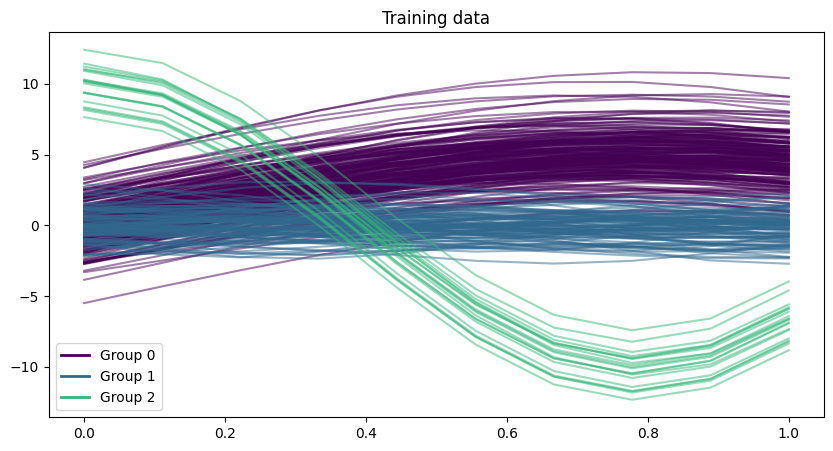

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = mpl.colormaps.get_cmap('viridis')
for i in range(len(Xs)):
    ax.plot(ts, Xs[i].detach().numpy().T, alpha=0.5, color=cmap(i/len(Xs)))

legend_elements = [Line2D([0], [0], color=cmap(i/len(Xs)), lw=2, label=f'Group {i}') 
                   for i in range(len(Xs))]
ax.legend(handles=legend_elements)
ax.set_title("Training data")
plt.show()

In [6]:
m = torch.randn((K,T)) #torch.randn((K, F))
pi = torch.full((K,), 1/K)

kernels = [lambda x1, x2, s=s: rbf_kernel(x1, x2, sigma=s) for s in sigmas]

In [7]:
K_mat = torch.stack([kernel(t1, t2) for kernel in kernels]) * dt # [2 x 100 x 100]

evals, evecs = torch.linalg.eigh(K_mat)
# eigh returns eigenvalues in ascending order, so take the last R
evals, evecs = evals[..., -R:], evecs[..., -R:]
evals, evecs = torch.flip(evals, dims=[-1]), torch.flip(evecs, dims=[-1])

In [8]:
"""
    X: [B, T]
    m: [K, T]
    evals: [K, R]
    evecs: [K, T, R]
    K_math: [K, T, T]
"""

def get_J(X, m, evals, evecs, alpha):
    p1 = 1/torch.sqrt(torch.prod(1 - 2*alpha*evals, dim=-1)) # [K]
    a1 = X[:, None, :] - m[None, :, :] # [B, K, T]
    b1 = torch.square(torch.sum(a1[..., None] * evecs[None], dim=2)*dt) # [B, K, R] # TODO
    c1 = b1 / (1-2*alpha*evals[None]) # [B, K, R]
    d1 = p1*torch.exp(alpha*torch.sum(c1, dim=-1))
    return torch.mean(d1, dim=0)


def get_I(X, m, evals, evecs, alpha):
    p2 = 1/torch.sqrt(torch.prod(1 - 2*alpha*(evals[None, :, :] + evals[:, None, :]),dim=-1))
    a2 = (m[None, :, :] - m[:, None, :])
    b2 = (evecs[None, :] + evecs[:, None])
    c2 = torch.square(torch.sum(a2[..., None] * b2, dim=2)*dt) # TODO
    d2 = c2 / (1-2*alpha*(evals[None, :]-evals[:, None]))
    return p2*torch.exp(alpha*torch.sum(d2, dim=-1))


def MMD(X, I, J):
    E1 = torch.mean(rbf_fkernel(X[None, :, :], X[:, None, :], dt, alpha=alpha))
    E2 = torch.dot(pi,J)
    E3 = torch.dot(pi,I @ pi)
    return E1, E2, E3

In [10]:
m = nn.Parameter(torch.randn((K,T)))
pi = nn.Parameter(torch.full((K,), 1/K))
J = get_J(X, m, evals, evecs, alpha)
I = get_I(X, m, evals, evecs, alpha)
E1, E2, E3 = MMD(X, I, J)
MMD(X, I, J)

(tensor(0.9107),
 tensor(0.9854, grad_fn=<DotBackward0>),
 tensor(0.9883, grad_fn=<DotBackward0>))

In [11]:
optimizer = torch.optim.Adam([m, pi], lr=0.1)
pbar = tqdm(range(1000))
for i in pbar:
    optimizer.zero_grad()
    
    J = get_J(X, m, evals, evecs, alpha)
    I = get_I(X, m, evals, evecs, alpha)
    E1, E2, E3 = MMD(X, I, J)
    loss_reg = torch.sum(m.square(), axis=0).sum()*dt

    loss = (E1 - 2*E2 + E3) + loss_reg*lambd_reg
    loss.backward()
    optimizer.step()
    pi.data.clamp_(0.,1.)
    pi.data /= 1e-7+torch.sum(pi.data)
    pbar.set_description(f"Total loss: {loss.item():.4f}, E1: {E1.item():.4f}, E2: {E2.item():.4f}, E3: {E3.item():.4f}, loss_reg: {loss_reg.item():.4f}")

Total loss: -0.0741, E1: 0.9107, E2: 0.9876, E3: 0.9890, loss_reg: 1.3398: 100%|██████████| 1000/1000 [00:08<00:00, 117.47it/s]


In [12]:
estimated_pi = pi.detach().numpy()
print("Estimated pi: ", estimated_pi)
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.        0.9999999 0.       ]
True pi:  [0.625  0.3125 0.0625]


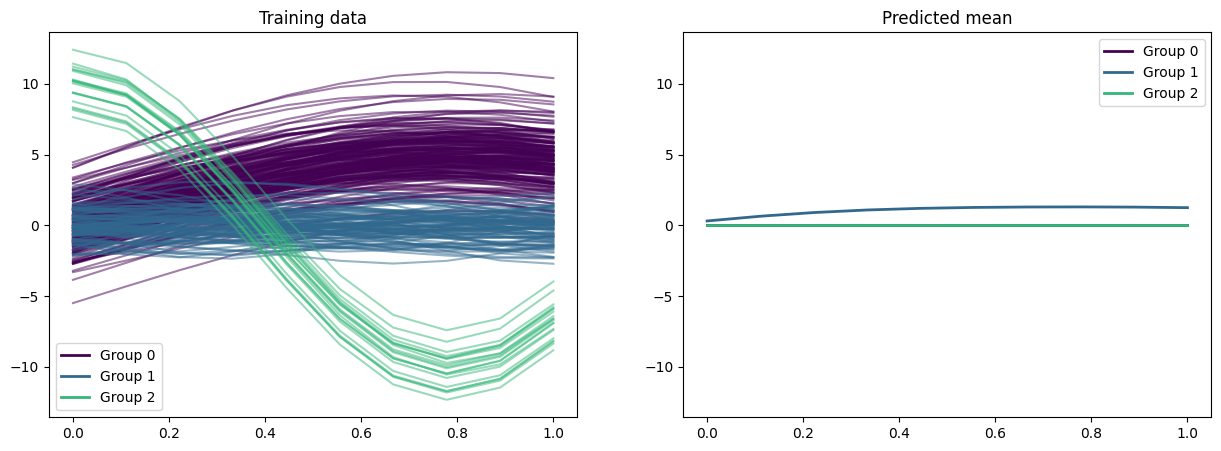

In [13]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15, 5))
cmap = mpl.colormaps.get_cmap('viridis')
for i in range(len(Xs)):
    ax1.plot(ts, Xs[i].detach().numpy().T, alpha=0.5, color=cmap(i/len(Xs)))

legend_elements = [Line2D([0], [0], color=cmap(i/len(Xs)), lw=2, label=f'Group {i}') 
                   for i in range(len(Xs))]
ax1.legend(handles=legend_elements)
ax1.set_title("Training data")

for i in range(K):
    ax2.plot(ts, m[i].detach().numpy(), color=cmap(i/K), lw=2, label=f'Group {i}')
ax2.legend()
ax2.set_title("Predicted mean")
ax2.set_ylim(ax1.get_ylim())
plt.show()

In [21]:
m = nn.Parameter(torch.randn((K,T)))
pi = torch.full((K,), 1/K)

In [22]:
optimizer = torch.optim.Adam([m], lr=0.01)
pbar = tqdm(range(1000))
for i in pbar:
    optimizer.zero_grad()
    
    J = get_J(X, m, evals, evecs, alpha)
    I = get_I(X, m, evals, evecs, alpha)
    E1, E2, E3 = MMD(X, I, J)
    loss_reg = torch.sum(m.square(), axis=0).sum()*dt

    loss = (E1 - 2*E2 + E3) + loss_reg*lambd_reg
    loss.backward()
    optimizer.step()

    if i%10==0:
        with torch.no_grad():
            I_inv = torch.inverse(I)
            Ones = torch.ones_like(pi)
            pi = I_inv @ J - ((torch.dot(Ones, I_inv @ J) - 1)/torch.dot(Ones, I_inv @ Ones)) * (I_inv @ Ones)
            pi.clamp_(0.,1.)
            pi /= 1e-7+torch.sum(pi)
    pbar.set_description(f"Total loss: {loss.item():.4f}, E1: {E1.item():.4f}, E2: {E2.item():.4f}, E3: {E3.item():.4f}, loss_reg: {loss_reg.item():.4f}")

Total loss: -0.0928, E1: 0.9107, E2: 0.9748, E3: 0.9004, loss_reg: 45.6644: 100%|██████████| 1000/1000 [00:09<00:00, 109.27it/s]


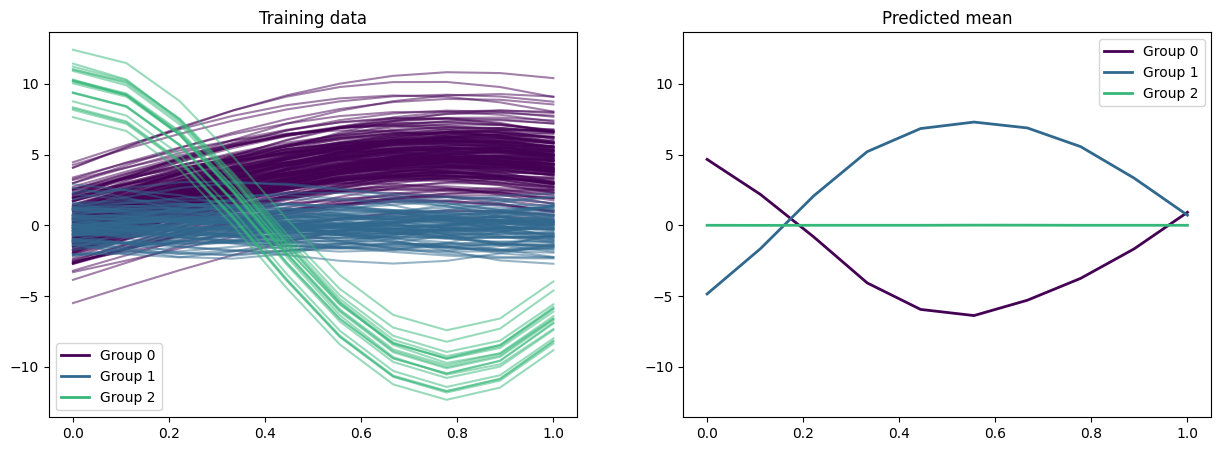

In [23]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15, 5))
cmap = mpl.colormaps.get_cmap('viridis')
for i in range(len(Xs)):
    ax1.plot(ts, Xs[i].detach().numpy().T, alpha=0.5, color=cmap(i/len(Xs)))

legend_elements = [Line2D([0], [0], color=cmap(i/len(Xs)), lw=2, label=f'Group {i}') 
                   for i in range(len(Xs))]
ax1.legend(handles=legend_elements)
ax1.set_title("Training data")

for i in range(K):
    ax2.plot(ts, m[i].detach().numpy(), color=cmap(i/K), lw=2, label=f'Group {i}')
ax2.legend()
ax2.set_title("Predicted mean")
ax2.set_ylim(ax1.get_ylim())
plt.show()

In [24]:
estimated_pi = pi.detach().numpy()
print("Estimated pi: ", estimated_pi)
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.5 0.5 0. ]
True pi:  [0.625  0.3125 0.0625]


## Test that Empirical MMD is the samme as Calculated

In [ ]:
# _m = nn.Parameter(torch.randn((K,T)))
# _pi = nn.Parameter(torch.full((K,), 1/K))

In [ ]:
x1 = MultivariateNormal(torch.zeros(T), rbf_kernel(t1, t2, sigma=sigmas[0]) + 1e-5 * torch.eye(T)).sample((900,))
x2 = MultivariateNormal(2*torch.ones(T), rbf_kernel(t1, t2, sigma=sigmas[1]) + 1e-5 * torch.eye(T)).sample((900,))
x = torch.concatenate([x1, x2], dim=0)

In [ ]:
y1 = MultivariateNormal(m[0], rbf_kernel(t1, t2, sigma=sigmas[0]) + 1e-5 * torch.eye(T)).sample((1000,))
y2 = MultivariateNormal(m[1], rbf_kernel(t1, t2, sigma=sigmas[1]) + 1e-5 * torch.eye(T)).sample((1000,))
y = torch.concatenate([y1, y2], dim=0)

In [ ]:
e1 = torch.mean(rbf_fkernel(x[None, :, :], x[:, None, :], dt, alpha=alpha))
e2 = rbf_fkernel(y[None, :, :], x[:, None, :], dt, alpha=alpha).mean(0).mean(0)
e3 = torch.mean(rbf_fkernel(y[None, :, :], y[:, None, :], dt, alpha=alpha))

loss = e1 - 2*e2 + e3

In [ ]:
E1, E2, E3 = MMD(x, m, pi, evals, evecs, alpha)

Loss = E1 - 2*E2 + E3

In [ ]:
print(f"Total loss: {loss.item():.4f}\nE1: {e1.item():.4f}, E2: {e2.item():.6f}, E3: {e3.item():.6f}")

Total loss: 0.0811
E1: 0.9793, E2: 0.932646, E3: 0.967107


In [ ]:
print(f"Total loss: {Loss.item():.4f}\nE1: {E1.item():.4f}, E2: {E2.item():.6f}, E3: {E3.item():.6f}")

Total loss: -0.0676
E1: 0.9793, E2: 0.984036, E3: 0.921177
